In [ ]:
# !pip install --upgrade keras
# !pip install numpy
# !pip install opencv-python
# !pip install visualkeras==0.1.4 keras_tuner==1.4.7 keras_cv==0.9.0 pydot==3.0.4 graphviz==0.20.3 git+https://github.com/raghakot/keras-vis.git

### IMPORT LIBRARY

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import time
import shutil
import random
import visualkeras 
import pandas as pd 
from collections import Counter
from scipy.stats import pearsonr
from tensorflow.keras.models import Sequential, load_model 
from tensorflow.keras.layers import Flatten, Dense, Dropout,GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.callbacks import CSVLogger, LambdaCallback
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split


### PRAPROSES 

#### Strategi Preprocessing: CLAHE pada Green Channel
Pada tahap ini, dilakukan perbaikan kualitas citra fundus menggunakan metode **CLAHE (Contrast Limited Adaptive Histogram Equalization)**. 

**Mengapa Green Channel?**
Secara spesifik mengekstrak **Green Channel** dari citra RGB karena pada citra fundus retina, *channel* hijau memiliki kontras terbaik dan memberikan detail pembuluh darah serta struktur mata yang paling jelas dibandingkan *channel* merah atau biru.

**Tujuan:**
1. Menstandarisasi pencahayaan citra.
2. Memperjelas fitur-fitur penting pada mata untuk mempermudah model membedakan mata normal dan katarak.

In [2]:
def preproses(images):
    
    # Konversi PIL ke NumPy
    image = cv2.imread(images)
    
    # Resize ukuran sesuai input model
    image = cv2.resize(image, (180, 180))
    
    # Ambil channel hijau (jika input masih RGB)
    green = image[:, :, 1]  # Ambil channel hijau dari gambar RGB
    
    # Terapkan CLAHE ke channel hijau
    clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(8, 8))
    cla = clahe.apply(green)
    
    # Konversi gambar ke grayscale setelah CLAHE
    gray_image = cv2.merge([cla, cla, cla])  # Konversi ke format 3-channel RGB untuk kompatibilitas dengan ImageDataGenerator
    
    # Normalisasi inputan
    normalisasi = gray_image.astype('float32') / 255.0   # kalau clahe ubah ke gray_image lagi
    
    return normalisasi


#### MENDEFINISIKAN FOLDER

In [ ]:
# Sumber path yang akan digunakan
dataset_path = "D:/kuliah/TA/PROGRAM/dataset/split/1000" #ubah sesuai kebutuhan dataset
base_output_path = "D:/kuliah/TA/PROGRAM/dataset klasifikasi/1000/clahe/80 20 new" #ubah sesuai hasil praproses
train_path = os.path.join(base_output_path, "train")
val_path = os.path.join(base_output_path, "val")
test_path = os.path.join(base_output_path, "test")
model_path = "D:/kuliah/TA/PROGRAM/savemodel" #ubah sesuai kebutuhan penyimpanan model

# Buat folder output
# for path in [train_path, test_path]: #val_path jgn lupa kalau 801010
#     for cls in ["cataract", "normal"]:
#         os.makedirs(os.path.join(path, cls), exist_ok=True)

#### Strategi Pembagian Data (Data Splitting)
Terdapat dua strategi pembagian **pertama** dibagi menjadi dua bagian rasio **80:20** dan **kedua** dibagi menjadi tiga bagian dengan rasio **80:10:10** untuk memastikan evaluasi yang objektif:
* **Training Set :** Digunakan untuk melatih bobot model.
* **Validation Set :** Digunakan untuk memantau performa saat training (mencegah *overfitting*).
* **Test Set :** Data "gaib" yang tidak pernah dilihat model, digunakan untuk evaluasi akhir.

> **Catatan:** Pastikan *path* dataset lokal disesuaikan sebelum menjalankan kode ini.

In [ ]:
# Fungsi split dan simpan hasil preprocessing
def split_and_save_data(class_name):
    class_dir = os.path.join(dataset_path, class_name)
    image_list = os.listdir(class_dir)
    random.shuffle(image_list)

    train_files, test_files = train_test_split(image_list, test_size=0.2, random_state=42) # kalau 80 20 pakai test_files setelah train_files
    # val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42) # kalau 80 10 10 test_files di baris diatas diubah ke temp_files

    def simpan_gambar(files, target_folder):
        for file in files:
            input_path = os.path.join(class_dir, file)
            output_path = os.path.join(target_folder, class_name, file)
            try:
                processed = preproses(input_path) #preproses
                processed = (processed * 255).astype(np.uint8)  # balik ke uint8 biar bisa disimpan
                cv2.imwrite(output_path, processed) # kalau clahe pake cv2.cvtColor(processed, cv2.COLOR_RGB2BGR)
            except Exception as e:
                print(f"Gagal proses gambar {file}: {e}")

    simpan_gambar(train_files, train_path)
    # simpan_gambar(val_files, val_path) # ini untuk 80 10 10
    simpan_gambar(test_files, test_path)

# Proses seluruh kelas
split_and_save_data("cataract")
split_and_save_data("normal")

print("Preprocessing dan pembagian data selesai.")


In [ ]:
# ImageDataGenerator (tanpa augmentasi, karena sudah preprocessed)
datagen = ImageDataGenerator(rescale=1./255)

IMG_WIDTH, IMG_HEIGHT = 180, 180
BATCH_SIZE = 32

# Buat generator untuk data training dengan resize otomatis
train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(IMG_WIDTH, IMG_HEIGHT),  # Resize otomatis oleh ImageDataGenerator
    batch_size=32,
    class_mode='binary',
    color_mode='rgb'  # Menggunakan RGB meskipun gambar sudah grayscale (karena generator mengharapkan 3 channel)
)

# Buat generator untuk data validation dengan resize otomatis
val_generator = datagen.flow_from_directory(
    val_path,
    target_size=(IMG_WIDTH, IMG_HEIGHT),  # Resize otomatis oleh ImageDataGenerator
    batch_size=32,
    class_mode='binary',
    color_mode='rgb'  # Menggunakan RGB meskipun gambar sudah grayscale (karena generator mengharapkan 3 channel)
)

# Buat generator untuk data validation dengan resize otomatis
test_generator = datagen.flow_from_directory(
    test_path,
    target_size=(IMG_WIDTH, IMG_HEIGHT),  # Resize otomatis oleh ImageDataGenerator
    batch_size=32,
    class_mode='binary',
    color_mode='rgb'  # Menggunakan RGB meskipun gambar sudah grayscale (karena generator mengharapkan 3 channel)
)

Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


#### MENGECEK KELAS DATASET

In [ ]:
train_generator.class_indices
test_generator.class_indices
val_generator.class_indices

{'0-normal': 0, '1-cataract': 1}

#### JUMLAH DATA TIAP FOLDER

In [ ]:
print(f"Jumlah data training: {train_generator.samples}")
print(f"Jumlah data validasi: {val_generator.samples}")
print(f"Jumlah data test: {test_generator.samples}")



Jumlah data training: 1690
Jumlah data test: 422


#### MENGECEK DISTRIBUSI DATA TIAP FOLDER

In [ ]:
# Ambil semua label dari train_generator
train_labels = train_generator.classes
val_labels = val_generator.classes
test_labels = test_generator.classes

# Hitung jumlah gambar per kelas
train_count = Counter(train_labels)
val_count = Counter(val_labels)
test_count = Counter(test_labels)

print(f"Distribusi kelas pada data training: {dict(train_count)}")
print(f"Distribusi kelas pada data validasi: {dict(val_count)}")
print(f"Distribusi kelas pada data test: {dict(test_count)}")    
    

Distribusi kelas pada data training: {0: 859, 1: 831}
Distribusi kelas pada data test: {0: 215, 1: 207}


#### MENAMPILKAN DATASET SETELAH PREPROCESSING

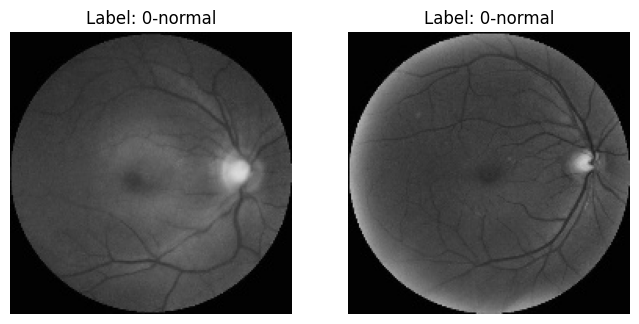

In [5]:
# Function untuk menampilkan gambar dalam satu baris
def display_images_side_by_side(images, labels, class_indices):
    class_labels = {v: k for k, v in class_indices.items()}  # Mapping indeks label ke nama kelas
    
    fig, axes = plt.subplots(1, len(images), figsize=(8, 4))  # Buat subplot dalam satu baris
    
    for i, ax in enumerate(axes):
        image = (images[i] * 255).astype("uint8")  # Konversi nilai pixel ke rentang 0-255
        label_name = class_labels.get(int(labels[i]), "Unknown")  # Mapping label
        
        ax.imshow(image)  # Tampilkan gambar
        ax.set_title(f"Label: {label_name}")  # Tambahkan judul label
        ax.axis('off')  # Hilangkan axis untuk tampilan lebih bersih
    
    plt.show()  # Tampilkan gambar

# Ambil satu batch dari train_generator
image_batch, label_batch = next(train_generator)

# Ambil class indices dari generator
class_indices = train_generator.class_indices

# Pilih dua gambar pertama dari batch
selected_images = [image_batch[0], image_batch[1]]
selected_labels = [label_batch[0], label_batch[1]]

# Tampilkan dua gambar secara berdampingan
display_images_side_by_side(selected_images, selected_labels, class_indices)


#### MENGECEK TIPE DATA SETELAH CLAHE DAN NORMALISASI

In [28]:
batch = next(iter(train_generator))
print(batch[0].dtype)  # Harusnya float32


float32


### PEMBUATAN MODEL
#### Arsitektur Model & Transfer Learning
Pendekatan yang digunakan **Transfer Learning** dengan arsitektur **[VGG16 / MobileNetV2]** yang telah dilatih sebelumnya pada dataset ImageNet.

**Konfigurasi:**
1.  **Base Model (Frozen):** *Layer* ekstraksi fitur bawaan dibekukan (*trainable=False*) agar bobot fitur dasar tidak rusak saat pelatihan awal.
2.  **Custom Head:** Kami menambahkan *layer* baru (Flatten/GlobalAveragePooling -> Dense -> Dropout -> Output) yang khusus dilatih untuk klasifikasi biner (Katarak vs Normal).

#### MODEL VGG

In [ ]:
input_shape = (180, 180, 3)

base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

for layer in base_model.layers:
    layer.trainable = False

model_VGG2 = Sequential(name='model_VGG', layers=[
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid', name='output_model_VGG')
])

model_VGG2.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy',          # Basic accuracy metric
                                                                                        Precision(name='precision'),  # Precision metric
                                                                                        Recall(name='recall'),        # Recall metric
                                                                                        AUC(name='auc'),      # Area Under ROC Curve (AUC)
                                                                                        ])

In [ ]:
import psutil

# Mendefinisikan nama file
model_name = 'model_VGG1_2C' #ubah sesuai model 
model_file = os.path.join(model_path, f"{model_name}.h5")
csv_file = os.path.join(model_path, f'{model_name}.csv')
time_memori_file = os.path.join(model_path, 'time.csv')

# Callback untuk menyimpan log training model ke bentuk CSV
csv_log = CSVLogger(csv_file, separator=',', append=False)

# Mengecek apakah model sudah ada untuk menghindari training ulang
if os.path.exists(model_file) and os.path.exists(csv_file):
    
    # Load model yang sudah ada
    model_VGG2 = load_model(model_file)
    model_VGG2.summary()

else:
    # Monitoring memori dan waktu
    process = psutil.Process(os.getpid())
    memori_awal = process.memory_info().rss / 1024 ** 2 # dalam mb
    start_time = time.time()
    
    # Load model yang belum ada
    model_VGG2.summary()

    # Inisialisasi list untuk menyimpan nilai metrik
    train_accuracy_list = []
    val_accuracy_list = []
    train_loss_list = []
    val_loss_list = []

    # Training model
    history = model_VGG2.fit(
        train_generator,
        epochs=30,  
        validation_data=test_generator,
        callbacks = [
            csv_log,
            LambdaCallback(
                on_epoch_end=lambda epoch, logs:(
                    train_accuracy_list.append(logs['accuracy']),
                    val_accuracy_list.append(logs['val_accuracy']),
                    train_loss_list.append(logs['loss']),
                    val_loss_list.append(logs['val_loss'])
                )
            )
        ]
    )
    
    end_time = time.time()
    memori_akhir = process.memory_info().rss / 1024 ** 2 # dalam mb
    total_time = end_time - start_time

    # Menyimpan model ke bentuk h5
    model_VGG2.save(model_file)
    
    # Menyimpan log waktu dan memori ke csv
    df_log = pd.DataFrame([{
        'Model': model_name,
        'Waktu Training (s)': round(total_time, 2),
        'CPU Memori Awal (MB)': round(memori_awal, 2),
        'CPU Memori Akhir (MB)': round(memori_akhir, 2)
    }])
    
    # Jika file log waktu sudah ada 
    if os.path.exists(time_memori_file):
        df_existing = pd.read_csv(time_memori_file)
        df_combine = pd.concat([df_existing, df_log], ignore_index=True)
    
    else:
        df_combine = df_log
    
    df_combine.to_csv(time_memori_file, index=False)
    print(f'Log waktu dan memori tersimpan di: {time_memori_file}')

# Load model kembali dari CSV

history_VGG2 = pd.read_csv(csv_file, sep=',', engine='python')


Model: "model_VGG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_model_VGG (Dense)        │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,353,347 (62.38 MB)

 Trainable params: 1,638,657 (6.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 2 (12.00 B)

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\visualkeras\layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


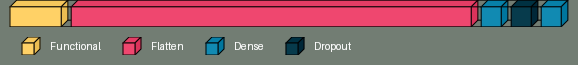

In [12]:
visualkeras.layered_view(model_VGG2, legend=True,background_fill='#727D73', font_color='white')

#### EVALUASI MODEL VGG

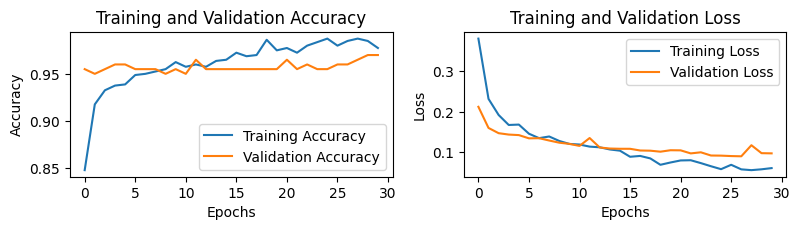

In [ ]:
# Visualisasi untuk Akurasi
plt.figure(figsize=(12, 4))

# Subplot 1: Training & Validation Accuracy
plt.subplot(2, 3, 1)
plt.plot(history_VGG2['accuracy'], label='Training Accuracy')
plt.plot(history_VGG2['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Subplot 2: Training & Validation Loss
plt.subplot(2, 3, 2)
plt.plot(history_VGG2['loss'], label='Training Loss')
plt.plot(history_VGG2['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Subplot 3: Training & Validation Precision
plt.subplot(2, 3, 2)
plt.plot(history_VGG2['precision'], label='Training Precision')
plt.plot(history_VGG2['val_precision'], label='Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.title('Training and Validation Precision')
plt.legend()

# Subplot 4: Training & Validation Recall
plt.subplot(2, 3, 3)
plt.plot(history_VGG2['recall'], label='Training Recall')
plt.plot(history_VGG2['val_recall'], label='Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.title('Training and Validation Recall')
plt.legend()

# Subplot 5: Training & Validation AUC
plt.subplot(2, 3, 4)
plt.plot(history_VGG2['auc'], label='Training AUC')
plt.plot(history_VGG2['val_auc'], label='Validation AUC')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.title('Training and Validation AUC')
plt.legend()

# Tampilkan Plot
plt.tight_layout()
plt.show()


In [9]:
# Evaluasi kinerja model pada data uji
test_loss, test_accuracy, test_precision, test_recall, test_auc = model_VGG2.evaluate(test_generator)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
print(f'Test Loss: {test_loss * 100:.2f}%')
print(f'Test Precision: {test_precision * 100:.2f}%')
print(f'Test Recall: {test_recall * 100:.2f}%')
print(f'Test AUC: {test_auc * 100:.2f}%')

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.9819 - auc: 0.9966 - loss: 0.0769 - precision: 0.9670 - recall: 0.9975
Test Accuracy: 97.00%
Test Loss: 9.74%
Test Precision: 95.19%
Test Recall: 99.00%
Test AUC: 99.53%


In [13]:
# Membaca file CSV model yang telah tersimpan
df_log = pd.read_csv(csv_file)

# Mengambil list metrik dari kolom csv
train_accuracy_list = df_log['accuracy'].tolist()
val_accuracy_list = df_log['val_accuracy'].tolist()
train_loss_list = df_log['loss'].tolist()
val_loss_list = df_log['val_loss'].tolist()

# Menghitung rata-rata dari list yang tersimpan
avg_train_accuracy = np.mean(train_accuracy_list)
avg_val_accuracy = np.mean(val_accuracy_list)
avg_train_loss = np.mean(train_loss_list)
avg_val_loss = np.mean(val_loss_list)

# Menghitung korelasi Pearson antara akurasi dan loss untuk train dan test
corr_accuracy, _ = pearsonr(train_accuracy_list, val_accuracy_list)
corr_loss, _ = pearsonr(train_loss_list, val_loss_list)

# Menampilkan hasil perhitungan
print(f'Average Training Accuracy: {avg_train_accuracy:.4f}')
print(f'Average Validation Accuracy: {avg_val_accuracy:.4f}')
print(f'Average Training Loss: {avg_train_loss:.4f}')
print(f'Average Validation Loss: {avg_val_loss:.4f}')
print(f'Pearson Correlation between Training and Validation Accuracy: {corr_accuracy:.4f}')
print(f'Pearson Correlation between Training and Validation Loss: {corr_loss:.4f}')


Average Training Accuracy: 0.9639
Average Validation Accuracy: 0.9596
Average Training Loss: 0.1035
Average Validation Loss: 0.1233
Pearson Correlation between Training and Validation Accuracy: 0.7473
Pearson Correlation between Training and Validation Loss: 0.9351


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 883ms/step


<Figure size 600x400 with 0 Axes>

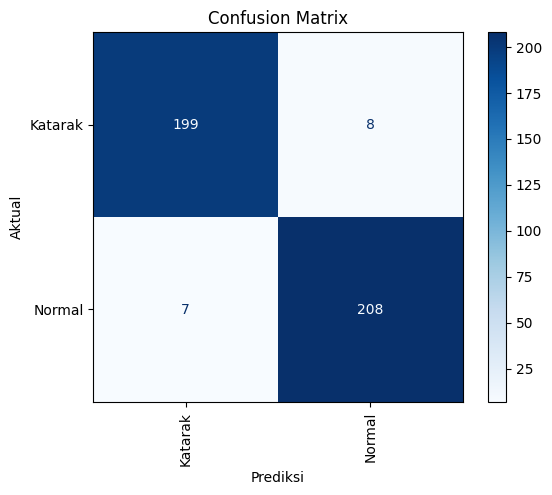

Classification Report:
              precision    recall  f1-score   support

     Katarak       0.97      0.96      0.96       207
      Normal       0.96      0.97      0.97       215

    accuracy                           0.96       422
   macro avg       0.96      0.96      0.96       422
weighted avg       0.96      0.96      0.96       422



In [11]:
# Ambil batch data dari generator validasi
y_true = []  # Simpan label asli
y_pred = []  # Simpan label prediksi

for images, labels in test_generator:
    # Lakukan prediksi
    predictions = model_VGG2.predict(images)
    
    # Konversi probabilitas ke label biner (threshold 0.5)
    predicted_labels = (predictions > 0.5).astype("int32")

    # Simpan hasil prediksi dan label asli
    y_true.extend(labels)
    y_pred.extend(predicted_labels)

    # Jika semua data sudah diproses, hentikan loop
    if len(y_true) >= test_generator.samples:
        break

# Konversi list ke numpy array
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Set label Katarak (1) sebagai kelas pertama, Normal (0) sebagai kedua
labels_order = [1, 0]  # Katarak, Normal
target_names = ["Katarak", "Normal"]

# Buat Confusion Matrix
cm_VGG2 = confusion_matrix(y_true, y_pred, labels=labels_order)

# Tampilkan Confusion Matrix dengan Heatmap
plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay(cm_VGG2, display_labels=target_names).plot(cmap='Blues',xticks_rotation='vertical')
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.show()

# Tampilkan Laporan Klasifikasi
print("Classification Report:")
report_VGG2 = classification_report(y_true, y_pred,labels=labels_order, target_names=target_names)
print(report_VGG2)


#### MODEL MOBILENET

In [10]:
input_shape = (180, 180, 3)  

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)

for layer in base_model.layers:
    layer.trainable = False

model_Mobilenet2 = Sequential(name='model_Mobilenet', layers=[
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_Mobilenet2.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy',          # Basic accuracy metric
                                                                                        Precision(name='precision'),  # Precision metric
                                                                                        Recall(name='recall'),        # Recall metric
                                                                                        AUC(name='auc'),      # Area Under ROC Curve (AUC)
                                                                                        ])



C:\Users\ASUS\AppData\Local\Temp\ipykernel_20372\1886946172.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)


In [ ]:
import psutil

# Mendefinikan nama file
model_name = 'model_Mobilenet1_2C' #ubah sesuai model
model_file = os.path.join(model_path, f"{model_name}.h5")
csv_file = os.path.join(model_path, f'{model_name}.csv')
time_memori_file = os.path.join(model_path, 'time.csv')

# Callback untuk menyimpan log training model ke bentuk CSV
csv_log = CSVLogger(csv_file, separator=',', append=False)

# Mengecek apakah model sudah ada untuk menghindari training ulang
if os.path.exists(model_file) and os.path.exists(csv_file):
    
    # Load model yang sudah ada
    model_Mobilenet2 = load_model(model_file)
    model_Mobilenet2.summary()

else:
    # Monitoring memori dan waktu
    process = psutil.Process(os.getpid())
    memori_awal = process.memory_info().rss / 1024 ** 2 # dalam mb
    start_time = time.time()
    
    # Load model yang belum ada
    model_Mobilenet2.summary()

    # Inisialisasi list untuk menyimpan nilai metrik
    train_accuracy_list = []
    val_accuracy_list = []
    train_loss_list = []
    val_loss_list = []

    # Training model
    history = model_Mobilenet2.fit(
        train_generator,
        epochs=30,  
        validation_data=test_generator,
        callbacks = [
            csv_log,
            LambdaCallback(
                on_epoch_end=lambda epoch, logs:(
                    train_accuracy_list.append(logs['accuracy']),
                    val_accuracy_list.append(logs['val_accuracy']),
                    train_loss_list.append(logs['loss']),
                    val_loss_list.append(logs['val_loss'])
                )
            )
        ]
    )
    
    end_time = time.time()
    memori_akhir = process.memory_info().rss / 1024 ** 2 # dalam mb
    total_time = end_time - start_time

    # Menyimpan model ke bentuk h5
    model_Mobilenet2.save(model_file)
    
    # Menyimpan log waktu dan memori ke csv
    df_log = pd.DataFrame([{
        'Model': model_name,
        'Waktu Training (s)': round(total_time, 2),
        'CPU Memori Awal (MB)': round(memori_awal, 2),
        'CPU Memori Akhir (MB)': round(memori_akhir, 2)
    }])
    
    # Jika file log waktu sudah ada 
    if os.path.exists(time_memori_file):
        df_existing = pd.read_csv(time_memori_file)
        df_combine = pd.concat([df_existing, df_log], ignore_index=True)
    
    else:
        df_combine = df_log
    
    df_combine.to_csv(time_memori_file, index=False)
    print(f'Log waktu dan memori tersimpan di: {time_memori_file}')

# Load model kembali dari CSV
history_Mobilenet2 = pd.read_csv(csv_file, sep=',', engine='python')


Model: "model_Mobilenet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,083 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\visualkeras\layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


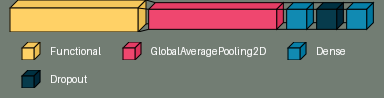

In [10]:
visualkeras.layered_view(model_Mobilenet2, legend=True,background_fill='#727D73', font_color='white')

#### EVALUASI MODEL MOBILENET

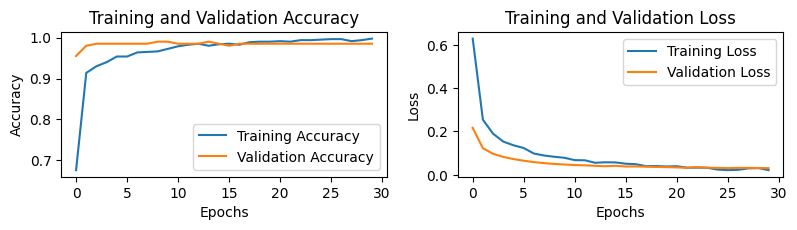

7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 359ms/step - accuracy: 0.9734 - auc: 0.9996 - loss: 0.0470 - precision: 0.9497 - recall: 1.0000
Test Accuracy: 98.50000143051147%
Test Loss: 3.0517838895320892%
Test Precision: 97.09%
Test Recall: 100.00%
Test AUC: 99.97%


In [ ]:
# Plot accuracy
plt.figure(figsize=(12, 4))

# Subplot 1: Training & Validation Accuracy
plt.subplot(2, 3, 1)
plt.plot(history_Mobilenet2['accuracy'], label='Training Accuracy')
plt.plot(history_Mobilenet2['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Subplot 2: Training & Validation Loss
plt.subplot(2, 3, 2)
plt.plot(history_Mobilenet2['loss'], label='Training Loss')
plt.plot(history_Mobilenet2['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Subplot 3: Training & Validation Precision
plt.subplot(2, 3, 3)
plt.plot(history_Mobilenet2['precision'], label='Training Precision')
plt.plot(history_Mobilenet2['val_precision'], label='Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.title('Training and Validation Precision')
plt.legend()

# Subplot 4: Training & Validation Recall
plt.subplot(2, 3, 4)
plt.plot(history_Mobilenet2['recall'], label='Training Recall')
plt.plot(history_Mobilenet2['val_recall'], label='Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.title('Training and Validation Recall')
plt.legend()

# Subplot 5: Training & Validation AUC
plt.subplot(2, 3, 5)
plt.plot(history_Mobilenet2['auc'], label='Training AUC')
plt.plot(history_Mobilenet2['val_auc'], label='Validation AUC')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.title('Training and Validation AUC')
plt.legend()

# Tampilkan Plot
plt.tight_layout()
plt.show()

# Evaluasi kinerja model pada data uji
test_loss2, test_accuracy2, test_precision2, test_recall2, test_auc2 = model_Mobilenet2.evaluate(test_generator)
print(f'Test Accuracy: {test_accuracy2 * 100}%')
print(f'Test Loss: {test_loss2 * 100}%')
print(f'Test Precision: {test_precision2 * 100:.2f}%')
print(f'Test Recall: {test_recall2 * 100:.2f}%')
print(f'Test AUC: {test_auc2 * 100:.2f}%')


In [40]:
# Membaca file CSV model yang telah tersimpan
df_log = pd.read_csv(csv_file)

# Mengambil list metrik dari kolom csv
train_accuracy_list = df_log['accuracy'].tolist()
val_accuracy_list = df_log['val_accuracy'].tolist()
train_loss_list = df_log['loss'].tolist()
val_loss_list = df_log['val_loss'].tolist()

# Menghitung rata-rata dari list yang tersimpan
avg_train_accuracy = np.mean(train_accuracy_list)
avg_val_accuracy = np.mean(val_accuracy_list)
avg_train_loss = np.mean(train_loss_list)
avg_val_loss = np.mean(val_loss_list)

# Menghitung korelasi Pearson antara akurasi dan loss untuk train dan test
corr_accuracy, _ = pearsonr(train_accuracy_list, val_accuracy_list)
corr_loss, _ = pearsonr(train_loss_list, val_loss_list)

# Menampilkan hasil perhitungan
print(f'Average Training Accuracy: {avg_train_accuracy:.4f}')
print(f'Average Validation Accuracy: {avg_val_accuracy:.4f}')
print(f'Average Training Loss: {avg_train_loss:.4f}')
print(f'Average Validation Loss: {avg_val_loss:.4f}')
print(f'Pearson Correlation between Training and Validation Accuracy: {corr_accuracy:.4f}')
print(f'Pearson Correlation between Training and Validation Loss: {corr_loss:.4f}')


Average Training Accuracy: 0.9602
Average Validation Accuracy: 0.9548
Average Training Loss: 0.1117
Average Validation Loss: 0.1228
Pearson Correlation between Training and Validation Accuracy: 0.7724
Pearson Correlation between Training and Validation Loss: 0.9504


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


<Figure size 600x400 with 0 Axes>

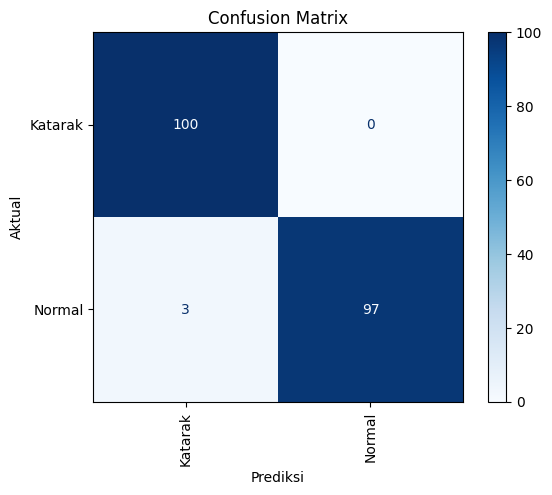

Classification Report:
              precision    recall  f1-score   support

     Katarak       0.97      1.00      0.99       100
      Normal       1.00      0.97      0.98       100

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



In [7]:
# Ambil batch data dari generator validasi
y_true = []  # Simpan label asli
y_pred = []  # Simpan label prediksi

for images, labels in test_generator:
    # Lakukan prediksi
    predictions = model_Mobilenet2.predict(images)
    
    # Konversi probabilitas ke label biner (threshold 0.5)
    predicted_labels = (predictions > 0.5).astype("int32")

    # Simpan hasil prediksi dan label asli
    y_true.extend(labels)
    y_pred.extend(predicted_labels)

    # Jika semua data sudah diproses, hentikan loop
    if len(y_true) >= test_generator.samples:
        break

# Konversi list ke numpy array
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Set label Normal (1) sebagai kelas pertama, Katarak (0) sebagai kedua
labels_order = [1, 0]  # Normal, Katarak
target_names = ["Katarak", "Normal"]

# Buat Confusion Matrix
cm_Mobilenet2 = confusion_matrix(y_true, y_pred, labels=labels_order)

# Tampilkan Confusion Matrix dengan Heatmap
plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay(cm_Mobilenet2, display_labels=target_names).plot(cmap='Blues', xticks_rotation='vertical')
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.show()

# Tampilkan Laporan Klasifikasi
report_Mobilenet2 = classification_report(y_true, y_pred, labels=labels_order, target_names=target_names)
print("Classification Report:")
print(report_Mobilenet2)


#### PERBANDINGAN HASIL MODEL VGG DAN MOBILENET

Model VGG Test Accuracy: 0.9644549489021301 
Model Mobilenet Test Accuracy: 0.9668246507644653

Model VGG Report:
               precision    recall  f1-score   support

     Katarak       0.97      0.96      0.96       207
      Normal       0.96      0.97      0.97       215

    accuracy                           0.96       422
   macro avg       0.96      0.96      0.96       422
weighted avg       0.96      0.96      0.96       422
 

Model Mobilenet Report:
               precision    recall  f1-score   support

     Katarak       0.97      0.97      0.97       207
      Normal       0.97      0.97      0.97       215

    accuracy                           0.97       422
   macro avg       0.97      0.97      0.97       422
weighted avg       0.97      0.97      0.97       422



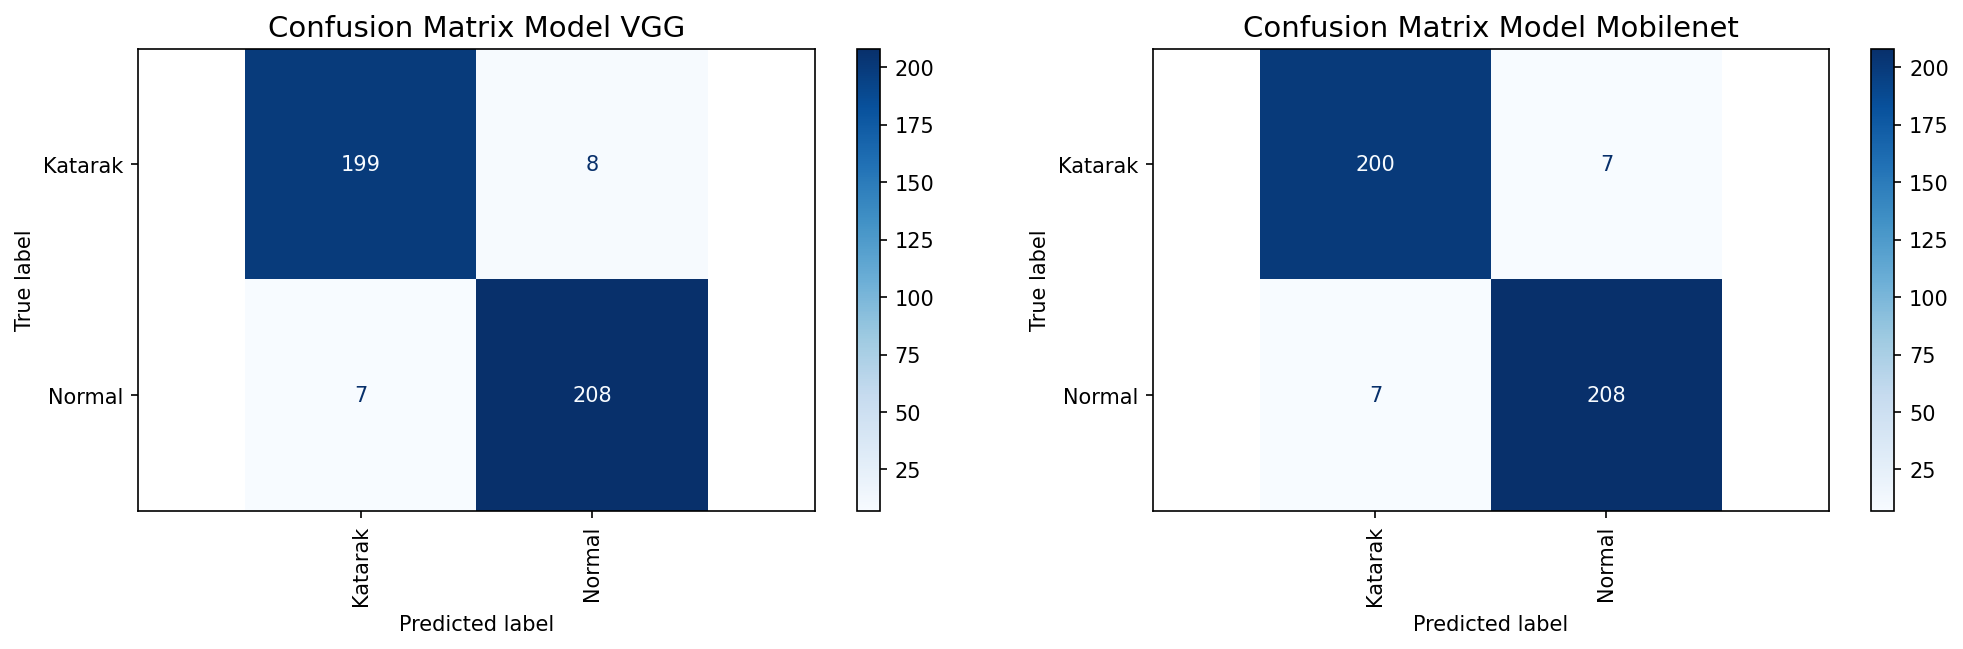

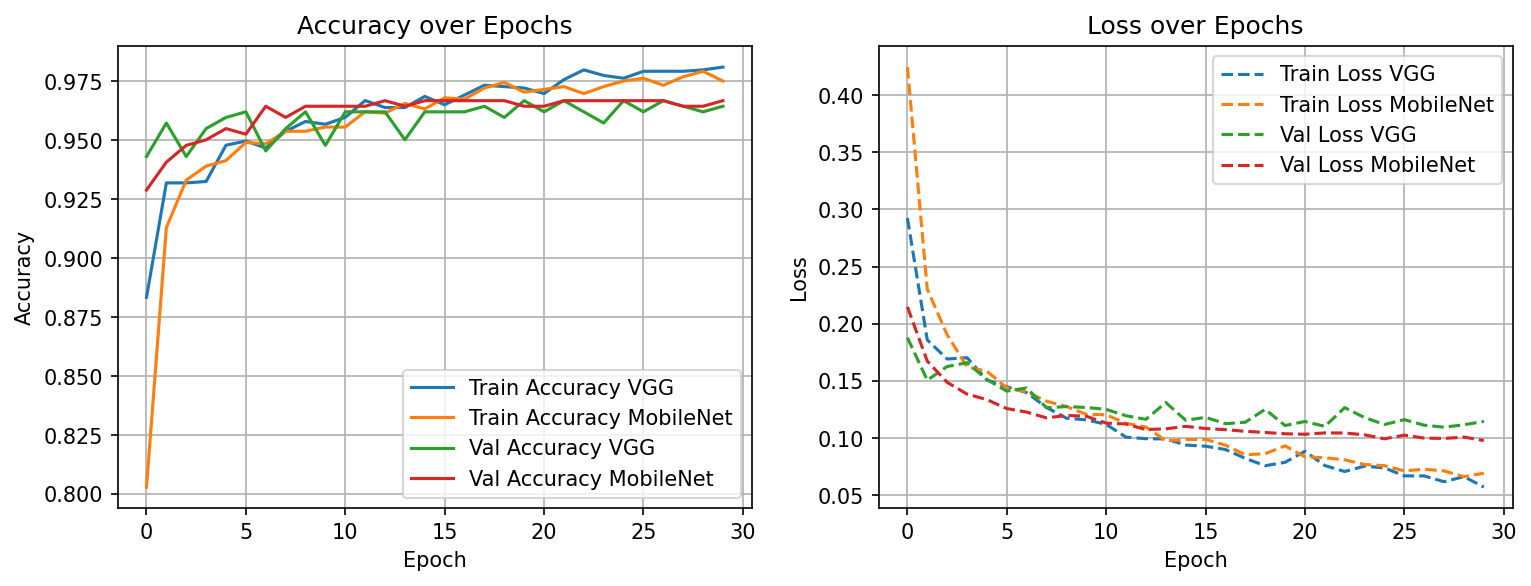

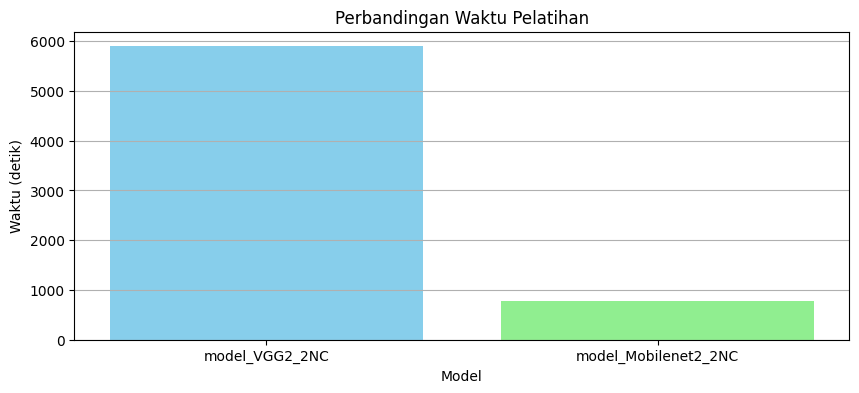

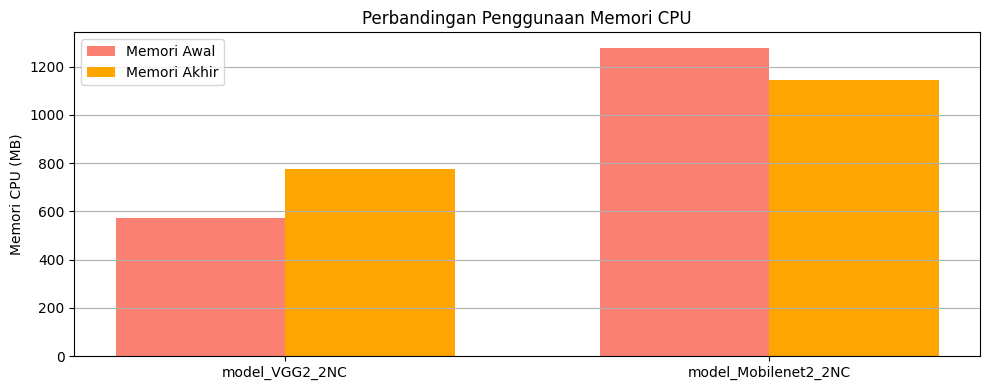

In [17]:
# Print Test Accuracies
print("Model VGG Test Accuracy:", test_accuracy, "\nModel Mobilenet Test Accuracy:" , test_accuracy2)

# Print Classification Reports
print("\nModel VGG Report:\n", report_VGG2, "\n\nModel Mobilenet Report:\n" ,report_Mobilenet2)

# Plot Confusion Matrix of both Models
fig, axs = plt.subplots(1, 2, figsize=(16, 4), dpi=150)

# Set label Normal (1) sebagai kelas pertama, Katarak (0) sebagai kedua
labels_order = [1, 0]  # Normal, Katarak
target_names = ["Katarak", "Normal"]

# axs[0] Confusion Matrix Model 1
ConfusionMatrixDisplay(cm_VGG2, display_labels=target_names).plot(cmap='Blues', xticks_rotation='vertical', ax=axs[0])
axs[0].set_title("Confusion Matrix Model VGG", fontsize=14)
axs[0].set_adjustable('datalim')

# axs[0,1] Confusion Matrix Model 2
ConfusionMatrixDisplay(cm_Mobilenet2, display_labels=target_names).plot(cmap='Blues', xticks_rotation='vertical', ax=axs[1])
axs[1].set_title("Confusion Matrix Model Mobilenet", fontsize=14)
axs[1].grid(False)
axs[1].set_adjustable('datalim')

# plot grafik akurasi dan loss
fig, axs = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

# === Grafik Akurasi ===
axs[0].plot(history_VGG2['accuracy'], label='Train Accuracy VGG')
axs[0].plot(history_Mobilenet2['accuracy'], label='Train Accuracy MobileNet')
axs[0].plot(history_VGG2['val_accuracy'], label='Val Accuracy VGG')
axs[0].plot(history_Mobilenet2['val_accuracy'], label='Val Accuracy MobileNet')
axs[0].set_title("Accuracy over Epochs")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Accuracy")
axs[0].legend(loc='lower right')
axs[0].grid(True)

# === Grafik Loss ===
axs[1].plot(history_VGG2['loss'], linestyle='--', label='Train Loss VGG')
axs[1].plot(history_Mobilenet2['loss'], linestyle='--', label='Train Loss MobileNet')
axs[1].plot(history_VGG2['val_loss'], linestyle='--', label='Val Loss VGG')
axs[1].plot(history_Mobilenet2['val_loss'], linestyle='--', label='Val Loss MobileNet')
axs[1].set_title("Loss over Epochs")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Loss")
axs[1].legend(loc='upper right')
axs[1].grid(True)

# Membaca file csv waktu dan penggunaan cpu
df = pd.read_csv(time_memori_file)

# Mengambil row sesuai model yang akan ditampilkan
df_filter = df[df['Model'].isin(['model_VGG2_2NC', 'model_Mobilenet2_2NC'])]

# Menampilkan waktu dan penggunaan cpu
plt.figure(figsize=(10, 4))
plt.bar(df_filter['Model'], df_filter['Waktu Training (s)'], color=['skyblue', 'lightgreen'])
plt.title('Perbandingan Waktu Pelatihan')
plt.ylabel('Waktu (detik)')
plt.xlabel('Model')
plt.grid(axis='y')
plt.show()

# Menampilkan penggunaan memori CPU
plt.figure(figsize=(10, 4))
bar_width = 0.35
index = range(len(df_filter))

plt.bar(index, df_filter['CPU Memori Awal (MB)'], bar_width, label='Memori Awal', color='salmon')
plt.bar([i + bar_width for i in index], df_filter['CPU Memori Akhir (MB)'], bar_width, label='Memori Akhir', color='orange')

plt.xticks([i + bar_width / 2 for i in index], df_filter['Model'])
plt.ylabel('Memori CPU (MB)')
plt.title('Perbandingan Penggunaan Memori CPU')
plt.legend()
plt.grid(axis='y')
plt.tight_layout()

# Show Plot
plt.show()